In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Loading Data 

In [3]:
Data = pd.read_csv("/Users/promojz/Documents/Future Interns/Data/online_retail.csv")

## Basic Info

In [4]:
Data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
Data.info()
Data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
Data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Data Cleaning & Feature Engineering 

In [7]:
# Convert InvoiceDate to datetime
Data['InvoiceDate'] = pd.to_datetime(Data['InvoiceDate'])

# Create Revenue column
Data['Revenue'] = Data['Quantity'] * Data['UnitPrice']

# Extract date components for analysis
Data['Year'] = Data['InvoiceDate'].dt.year
Data['Month'] = Data['InvoiceDate'].dt.month
Data['YearMonth'] = Data['InvoiceDate'].dt.to_period('M')
Data['DayOfWeek'] = Data['InvoiceDate'].dt.day_name()
Data['Hour'] = Data['InvoiceDate'].dt.hour

# Remove rows with missing CustomerID (can't analyze customer behavior without ID)
Data_clean = Data.dropna(subset=['CustomerID']).copy()

# Remove negative quantities (returns) for revenue analysis - we'll analyze them separately
# But keep them for now and flag them
Data_clean['IsReturn'] = Data_clean['Quantity'] < 0
Data_clean['IsCancelled'] = Data_clean['InvoiceNo'].str.startswith('C')

print(f"Original dataset: {Data.shape[0]} rows")
print(f"After removing missing CustomerID: {Data_clean.shape[0]} rows")
print(f"Returns/Cancellations: {Data_clean['IsReturn'].sum()} rows")
print(f"Date range: {Data_clean['InvoiceDate'].min()} to {Data_clean['InvoiceDate'].max()}")
print(f"Unique customers: {Data_clean['CustomerID'].nunique()}")
print(f"Unique products: {Data_clean['StockCode'].nunique()}")
print(f"Unique countries: {Data_clean['Country'].nunique()}")

# Check data quality
print("\nData Quality Check:")
print(f"Negative unit prices: {(Data_clean['UnitPrice'] < 0).sum()}")
print(f"Zero unit prices: {(Data_clean['UnitPrice'] == 0).sum()}")
print(f"Countries: {Data_clean['Country'].unique()}")

Original dataset: 541909 rows
After removing missing CustomerID: 406829 rows
Returns/Cancellations: 8905 rows
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4372
Unique products: 3684
Unique countries: 37

Data Quality Check:
Negative unit prices: 0
Zero unit prices: 40
Countries: ['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Austria' 'Israel' 'Finland' 'Greece' 'Singapore' 'Lebanon'
 'United Arab Emirates' 'Saudi Arabia' 'Czech Republic' 'Canada'
 'Unspecified' 'Brazil' 'USA' 'European Community' 'Bahrain' 'Malta' 'RSA']


In [8]:
Data_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,YearMonth,DayOfWeek,Hour,IsReturn,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2010-12,Wednesday,8,False,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,False,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2010-12,Wednesday,8,False,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,False,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,False,False


In [9]:
Data_clean.to_csv("/Users/promojz/Documents/Future Interns/Data/cleaned_sales_data.csv", index=False)

## Revenue Trend Analysis 

/var/folders/dt/270h92w54nz_70b990272vbc0000gn/T/ipykernel_66504/3871812919.py:67: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dt/270h92w54nz_70b990272vbc0000gn/T/ipykernel_66504/3871812919.py:68: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('/Users/promojz/Documents/Future Interns/python_viz/revenue_trends.png', dpi=300, bbox_inches='tight')
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


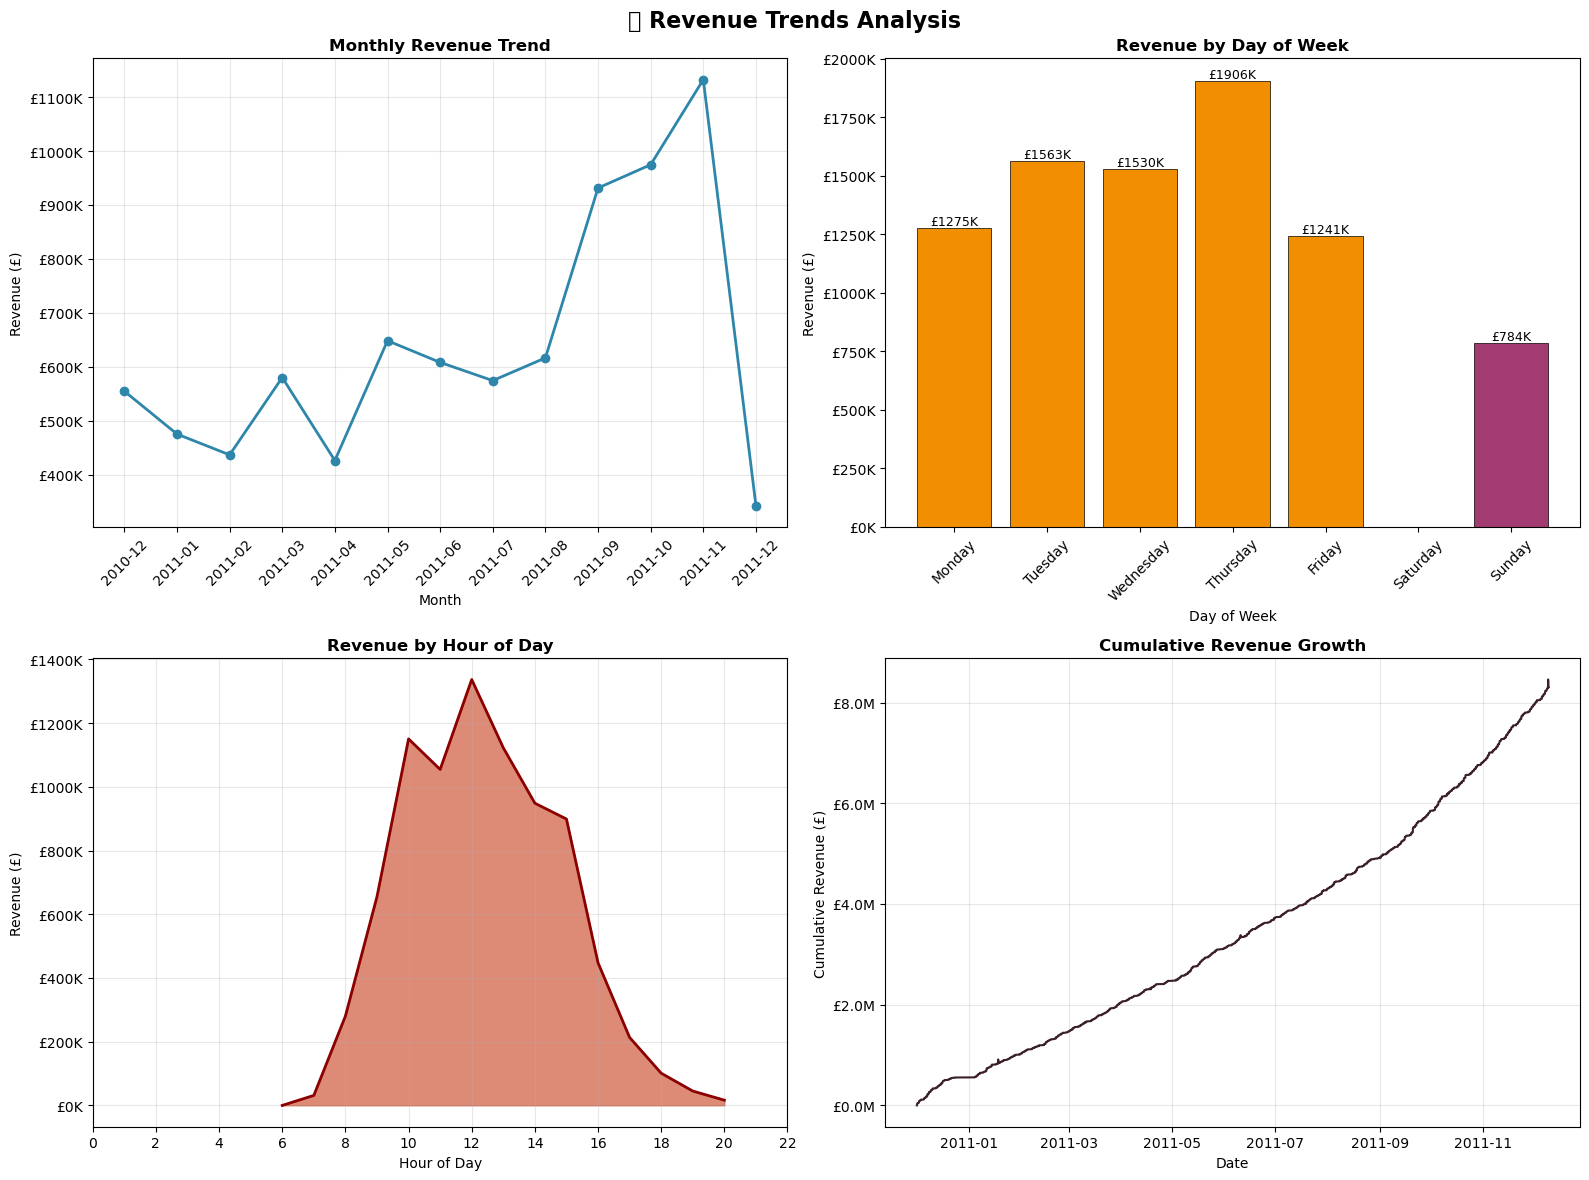

In [10]:
# Create a figure for Revenue Trends
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📈 Revenue Trends Analysis', fontsize=16, fontweight='bold', y=0.98)

# 1. Monthly Revenue Trend
monthly_revenue = Data_clean.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth_str'] = monthly_revenue['YearMonth'].astype(str)

ax1 = axes[0, 0]
ax1.plot(monthly_revenue['YearMonth_str'], monthly_revenue['Revenue'], 
         marker='o', linewidth=2, markersize=6, color='#2E86AB')
ax1.set_title('Monthly Revenue Trend', fontweight='bold', fontsize=12)
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (£)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
# Format y-axis to show values in thousands
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# 2. Daily Revenue Pattern (Day of Week)
daily_revenue = Data_clean.groupby('DayOfWeek')['Revenue'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

ax2 = axes[0, 1]
colors = ['#A23B72' if day in ['Saturday', 'Sunday'] else '#F18F01' for day in daily_revenue.index]
bars = ax2.bar(daily_revenue.index, daily_revenue.values, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Revenue by Day of Week', fontweight='bold', fontsize=12)
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Revenue (£)')
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'£{height/1000:.0f}K', ha='center', va='bottom', fontsize=9)


# 3. Hourly Revenue Pattern
hourly_revenue = Data_clean.groupby('Hour')['Revenue'].sum()

ax3 = axes[1, 0]
ax3.fill_between(hourly_revenue.index, hourly_revenue.values, alpha=0.6, color='#C73E1D')
ax3.plot(hourly_revenue.index, hourly_revenue.values, color='#8B0000', linewidth=2)
ax3.set_title('Revenue by Hour of Day', fontweight='bold', fontsize=12)
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Revenue (£)')
ax3.set_xticks(range(0, 24, 2))
ax3.grid(True, alpha=0.3)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# 4. Cumulative Revenue Growth
Data_sorted = Data_clean.sort_values('InvoiceDate')
Data_sorted['CumulativeRevenue'] = Data_sorted['Revenue'].cumsum()

ax4 = axes[1, 1]
ax4.plot(Data_sorted['InvoiceDate'], Data_sorted['CumulativeRevenue'], 
         color='#3B1F2B', linewidth=1.5)
ax4.set_title('Cumulative Revenue Growth', fontweight='bold', fontsize=12)
ax4.set_xlabel('Date')
ax4.set_ylabel('Cumulative Revenue (£)')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000000:.1f}M'))
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/promojz/Documents/Future Interns/python_viz/revenue_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
print(f"\nKey Insights:")
print(f"- Peak revenue month: {monthly_revenue.loc[monthly_revenue['Revenue'].idxmax(), 'YearMonth']} (£{monthly_revenue['Revenue'].max():,.2f})")
print(f"- Best performing day: {daily_revenue.idxmax()} (£{daily_revenue.max():,.2f})")
print(f"- Peak hour: {hourly_revenue.idxmax()}:00 (£{hourly_revenue.max():,.2f})")



Key Insights:
- Peak revenue month: 2011-11 (£1,132,407.74)
- Best performing day: Thursday (£1,906,108.19)
- Peak hour: 12:00 (£1,337,091.77)


## Top-Selling Product Analysis 

In [12]:
# Top products by Revenue
top_products_revenue = Data_clean.groupby(['StockCode', 'Description']).agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index().sort_values('Revenue', ascending=False).head(15)

# Top products by Quantity sold
top_products_quantity = Data_clean.groupby(['StockCode', 'Description']).agg({
    'Revenue': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique'
}).reset_index().sort_values('Quantity', ascending=False).head(15)

/var/folders/dt/270h92w54nz_70b990272vbc0000gn/T/ipykernel_66504/3721578187.py:70: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = top_100.pivot_table(values='Revenue', index='Price_Category',


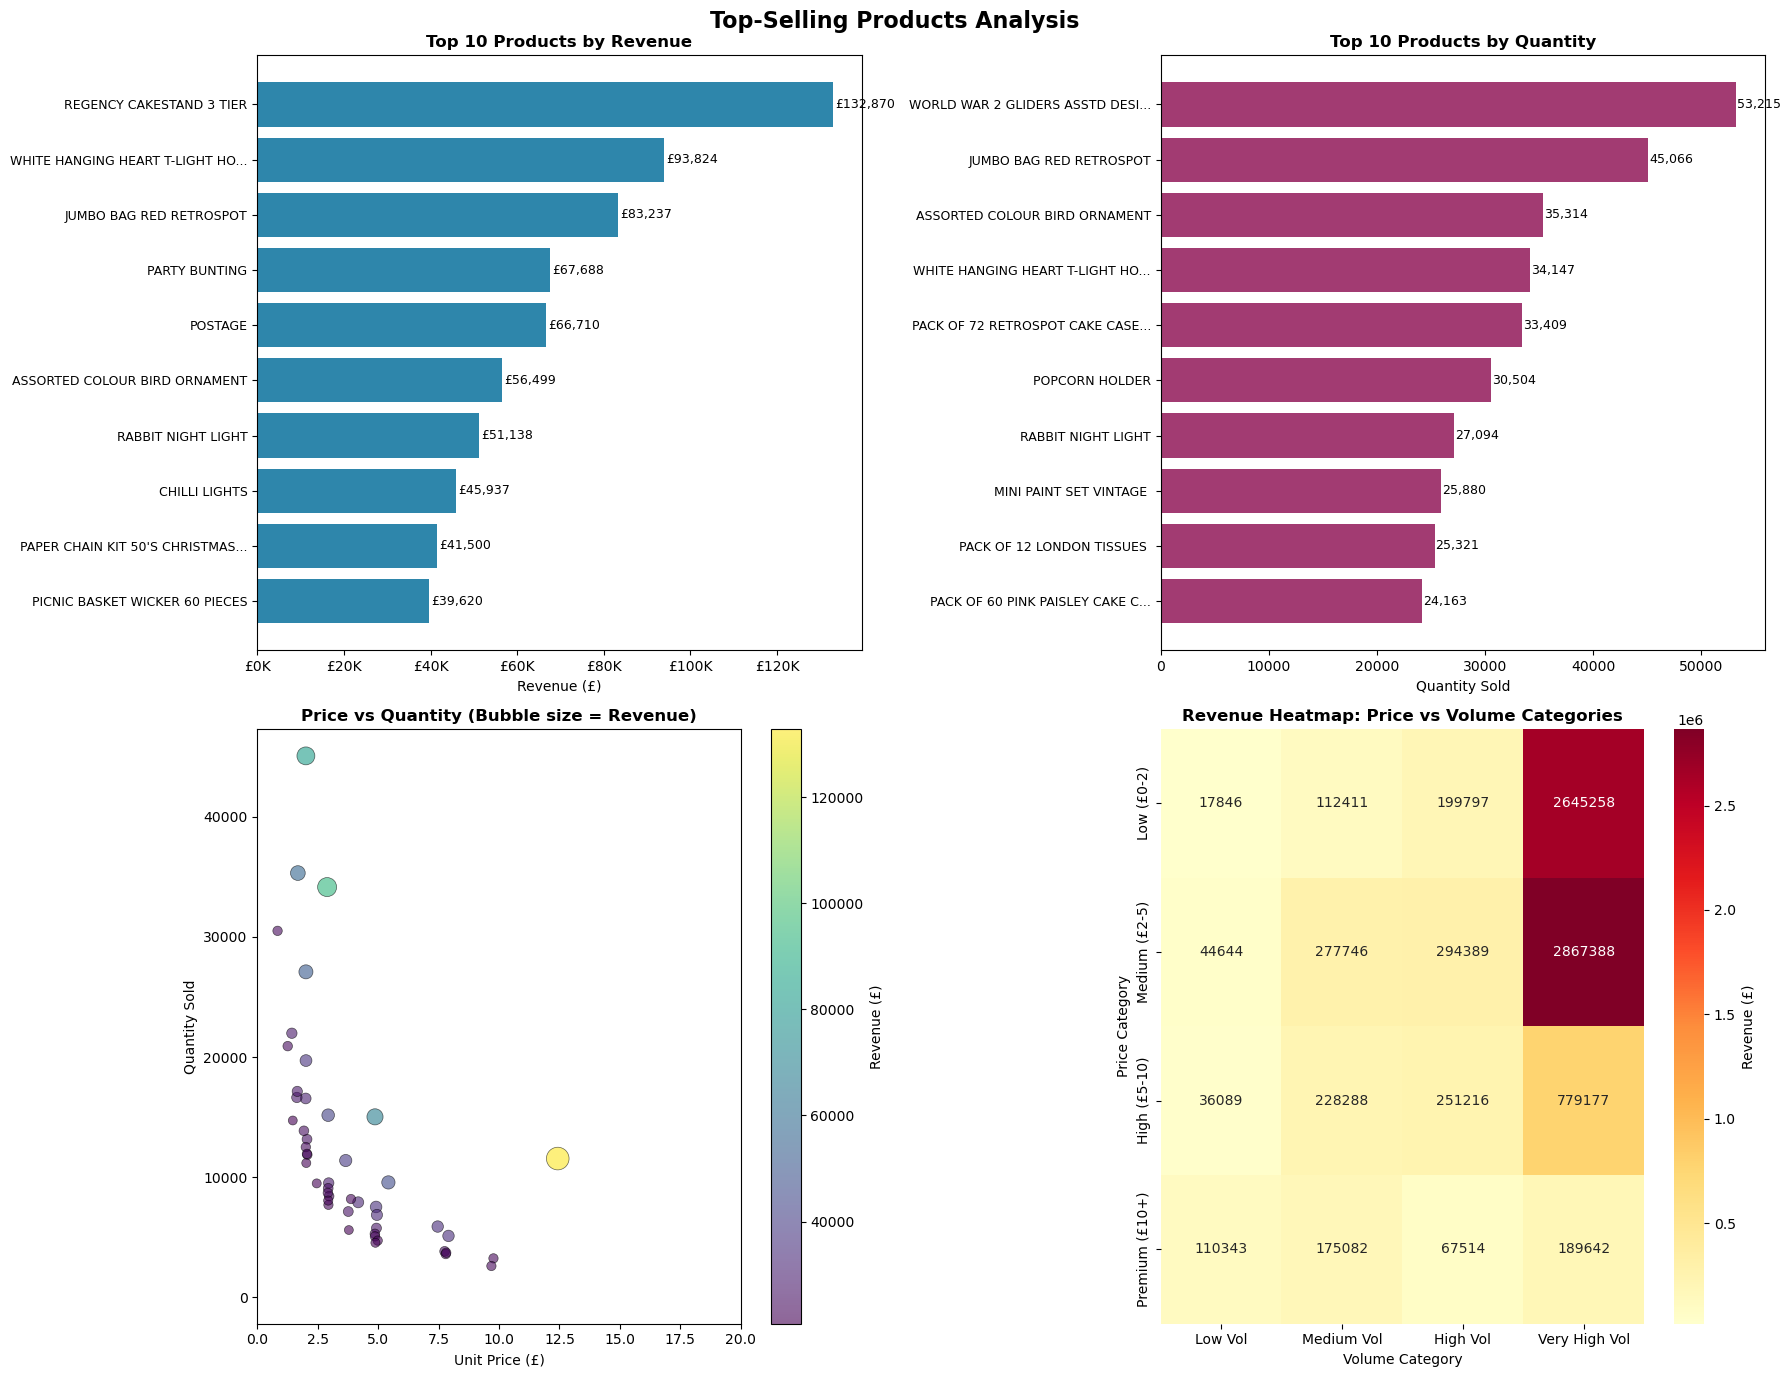


Top 5 Products by Revenue:
  1323. REGENCY CAKESTAND 3 TIER: £132,870.40
  3476. WHITE HANGING HEART T-LIGHT HOLDER: £93,823.85
  3461. JUMBO BAG RED RETROSPOT: £83,236.76
  2806. PARTY BUNTING: £67,687.53
  3916. POSTAGE: £66,710.24

Top 5 Products by Quantity:
  3029. WORLD WAR 2 GLIDERS ASSTD DESIGNS: 53,215 units
  3461. JUMBO BAG RED RETROSPOT: 45,066 units
  3289. ASSORTED COLOUR BIRD ORNAMENT: 35,314 units
  3476. WHITE HANGING HEART T-LIGHT HOLDER: 34,147 units
  435. PACK OF 72 RETROSPOT CAKE CASES: 33,409 units


In [13]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Top-Selling Products Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Top 10 Products by Revenue
ax1 = axes[0, 0]
top_10_rev = top_products_revenue.head(10)
labels = [desc[:30] + '...' if len(desc) > 30 else desc for desc in top_10_rev['Description']]
bars1 = ax1.barh(range(len(labels)), top_10_rev['Revenue'], color='#2E86AB')
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Revenue (£)')
ax1.set_title('Top 10 Products by Revenue', fontweight='bold', fontsize=12)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, top_10_rev['Revenue'])):
    ax1.text(val + 500, bar.get_y() + bar.get_height()/2, 
             f'£{val:,.0f}', va='center', fontsize=9)

# Plot 2: Top 10 Products by Quantity
ax2 = axes[0, 1]
top_10_qty = top_products_quantity.head(10)
labels2 = [desc[:30] + '...' if len(desc) > 30 else desc for desc in top_10_qty['Description']]
bars2 = ax2.barh(range(len(labels2)), top_10_qty['Quantity'], color='#A23B72')
ax2.set_yticks(range(len(labels2)))
ax2.set_yticklabels(labels2, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Quantity Sold')
ax2.set_title('Top 10 Products by Quantity', fontweight='bold', fontsize=12)

# Add value labels
for i, (bar, val) in enumerate(zip(bars2, top_10_qty['Quantity'])):
    ax2.text(val + 100, bar.get_y() + bar.get_height()/2, 
             f'{val:,.0f}', va='center', fontsize=9)

# Plot 3: Price vs Quantity Scatter (Top 50 products)
ax3 = axes[1, 0]
top_50 = Data_clean.groupby(['StockCode', 'Description']).agg({
    'UnitPrice': 'mean',
    'Quantity': 'sum',
    'Revenue': 'sum'
}).reset_index().sort_values('Revenue', ascending=False).head(50)

scatter = ax3.scatter(top_50['UnitPrice'], top_50['Quantity'], 
                     s=top_50['Revenue']/500, alpha=0.6, c=top_50['Revenue'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Unit Price (£)')
ax3.set_ylabel('Quantity Sold')
ax3.set_title('Price vs Quantity (Bubble size = Revenue)', fontweight='bold', fontsize=12)
ax3.set_xlim(0, 20)
plt.colorbar(scatter, ax=ax3, label='Revenue (£)')

# Plot 4: Product Performance Matrix
ax4 = axes[1, 1]
top_100 = Data_clean.groupby(['StockCode', 'Description']).agg({
    'UnitPrice': 'mean',
    'Quantity': 'sum',
    'Revenue': 'sum'
}).reset_index()

top_100['Price_Category'] = pd.cut(top_100['UnitPrice'], 
                                   bins=[0, 2, 5, 10, float('inf')], 
                                   labels=['Low (£0-2)', 'Medium (£2-5)', 'High (£5-10)', 'Premium (£10+)'])
top_100['Volume_Category'] = pd.cut(top_100['Quantity'], 
                                    bins=[0, 100, 500, 1000, float('inf')], 
                                    labels=['Low Vol', 'Medium Vol', 'High Vol', 'Very High Vol'])

pivot_data = top_100.pivot_table(values='Revenue', index='Price_Category', 
                                  columns='Volume_Category', aggfunc='sum')
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Revenue (£)'})
ax4.set_title('Revenue Heatmap: Price vs Volume Categories', fontweight='bold', fontsize=12)
ax4.set_xlabel('Volume Category')
ax4.set_ylabel('Price Category')

plt.tight_layout()
plt.savefig('/Users/promojz/Documents/Future Interns/python_viz/top_products.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 Products by Revenue:")
for i, row in top_products_revenue.head(5).iterrows():
    print(f"  {i+1}. {row['Description'][:50]}: £{row['Revenue']:,.2f}")

print("\nTop 5 Products by Quantity:")
for i, row in top_products_quantity.head(5).iterrows():
    print(f"  {i+1}. {row['Description'][:50]}: {row['Quantity']:,.0f} units")

## Category Analysis (Creating Product Categories)


Category Performance Summary:
                       Total_Revenue  Avg_Revenue  Num_Transactions  Total_Quantity  Num_Orders  Num_Customers
Category                                                                                                      
Other                     2465318.63        19.47            126636         1464192       17713           4120
Kitchen & Baking           961932.37        22.90             42011          477055       12121           3431
Bags & Storage             893827.24        21.87             40863          542815        8907           2674
Lighting & Candles         735850.29        25.44             28927          419535       10315           3180
Hearts & Romance           721832.49        18.94             38113          423000       11108           3397
Vintage Style              601660.83        19.91             30226          337617       10905           3302
Garden & Outdoor           428873.16        26.93             15926          1388

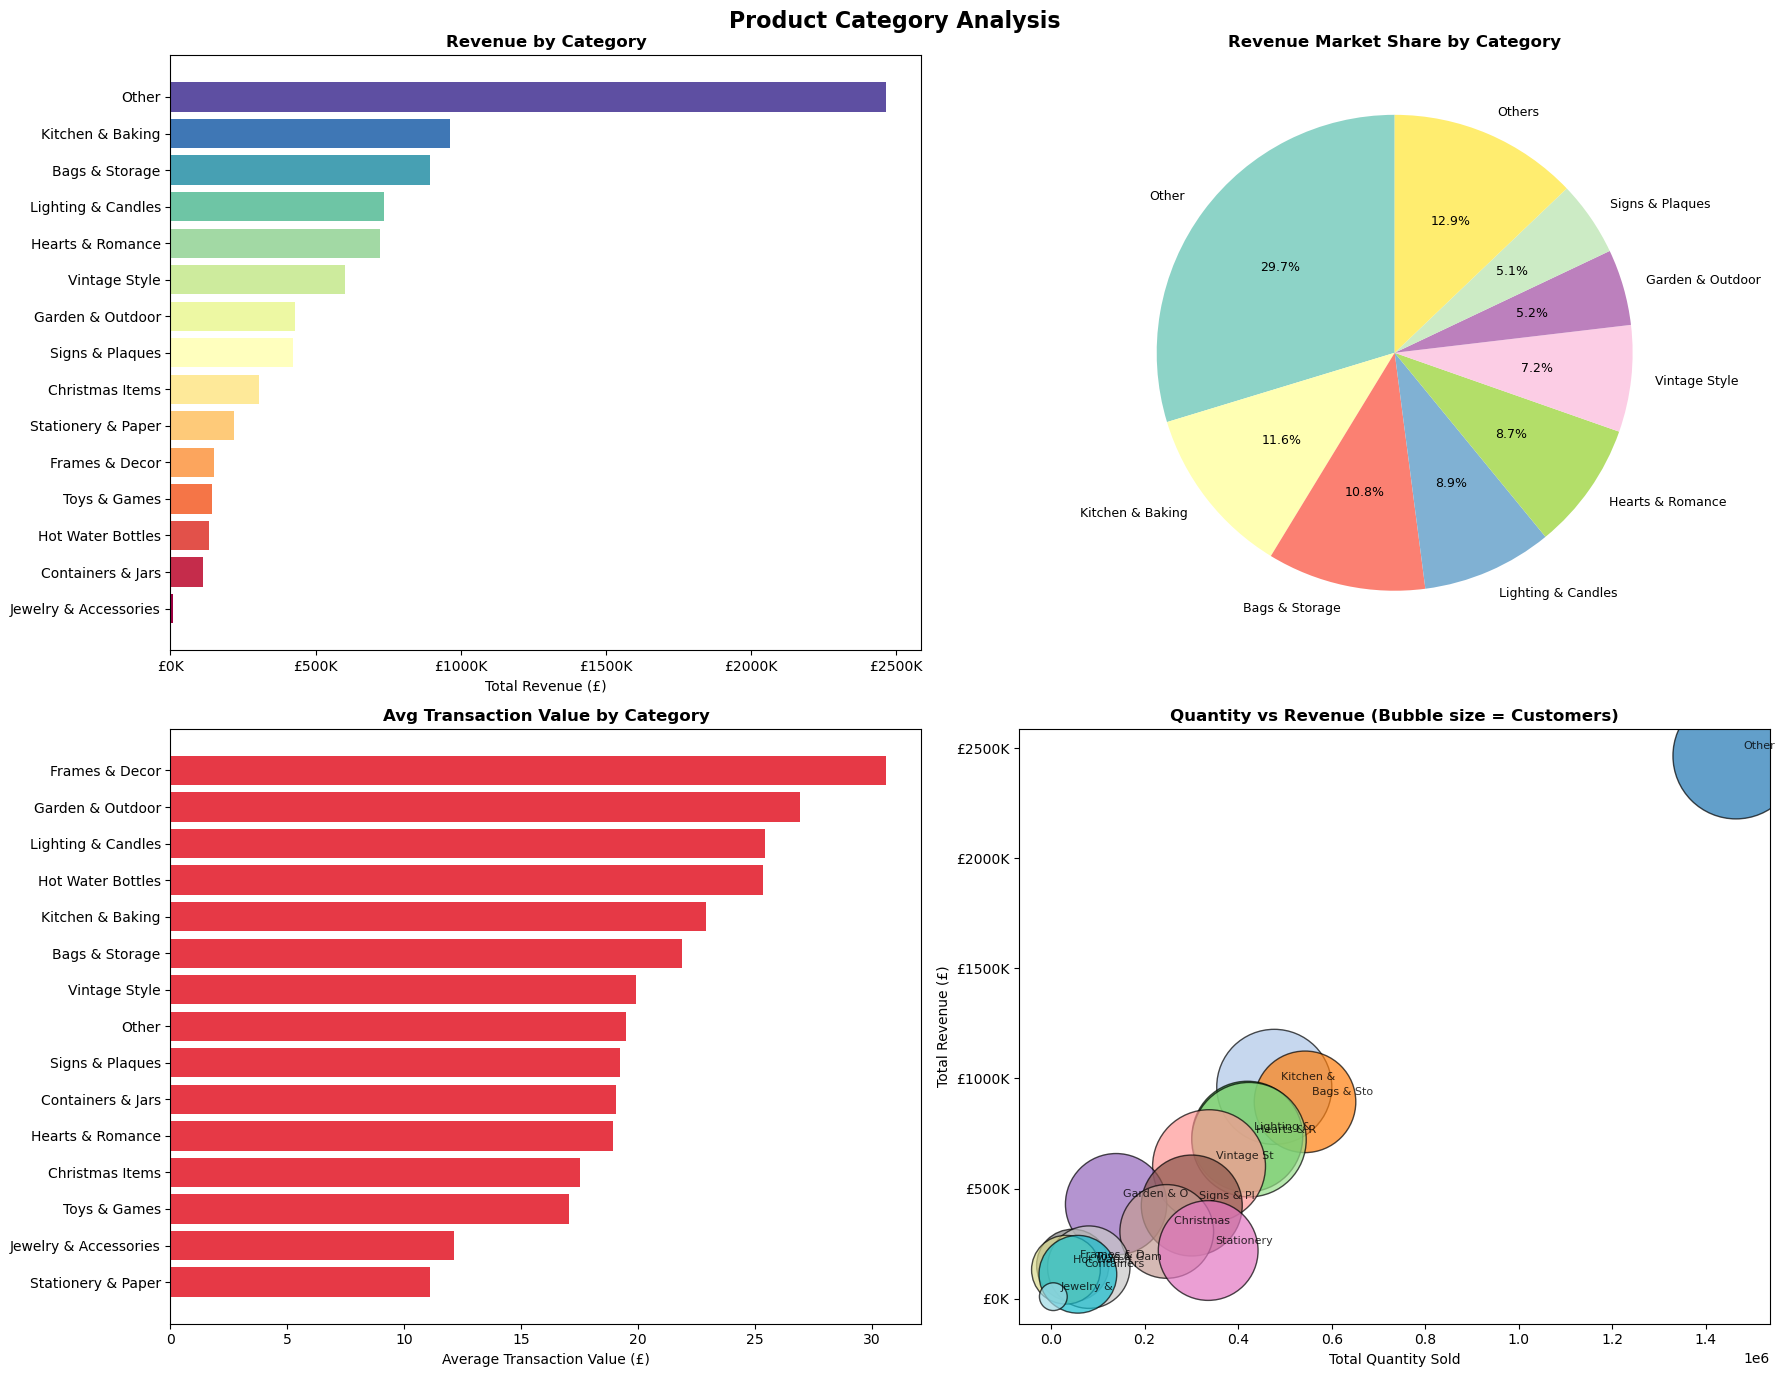


Key Category Insights:
- Top revenue category: Other (£2,465,318.63)
- Highest avg transaction: Frames & Decor (£30.58)
- Most popular by volume: Other (1,464,192 units)


In [14]:

# Create product categories based on description keywords
def categorize_product(description):
    if pd.isna(description):
        return 'Unknown'
    desc = description.upper()
    
    if any(word in desc for word in ['CANDLE', 'LIGHT', 'LANTERN', 'T-LIGHT', 'NIGHT LIGHT']):
        return 'Lighting & Candles'
    elif any(word in desc for word in ['BAG', 'SHOPPER', 'TOTE', 'LUNCH BAG', 'STORAGE BAG']):
        return 'Bags & Storage'
    elif any(word in desc for word in ['HEART', 'LOVE', 'WEDDING']):
        return 'Hearts & Romance'
    elif any(word in desc for word in ['CHRISTMAS', 'XMAS', 'SANTA', 'REINDEER', 'TREE']):
        return 'Christmas Items'
    elif any(word in desc for word in ['KITCHEN', 'CAKE', 'BAKING', 'COOKIE', 'TEA', 'COFFEE', 'MUG']):
        return 'Kitchen & Baking'
    elif any(word in desc for word in ['GARDEN', 'PLANT', 'FLOWER', 'DOORMAT']):
        return 'Garden & Outdoor'
    elif any(word in desc for word in ['VINTAGE', 'RETRO', 'ANTIQUE']):
        return 'Vintage Style'
    elif any(word in desc for word in ['TOY', 'GAME', 'DOLL', 'TEDDY', 'SOFT TOY']):
        return 'Toys & Games'
    elif any(word in desc for word in ['JEWELRY', 'NECKLACE', 'BRACELET', 'EARRING']):
        return 'Jewelry & Accessories'
    elif any(word in desc for word in ['FRAME', 'PICTURE', 'PHOTO']):
        return 'Frames & Decor'
    elif any(word in desc for word in ['HOT WATER BOTTLE', 'HOTTIE']):
        return 'Hot Water Bottles'
    elif any(word in desc for word in ['SIGN', 'METAL SIGN']):
        return 'Signs & Plaques'
    elif any(word in desc for word in ['PAPER', 'CARD', 'WRAP', 'NOTEBOOK', 'PENCIL']):
        return 'Stationery & Paper'
    elif any(word in desc for word in ['BOTTLE', 'JAR', 'CONTAINER']):
        return 'Containers & Jars'
    else:
        return 'Other'

# Apply categorization
Data_clean['Category'] = Data_clean['Description'].apply(categorize_product)

# Category analysis
category_stats = Data_clean.groupby('Category').agg({
    'Revenue': ['sum', 'mean', 'count'],
    'Quantity': 'sum',
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique'
}).round(2)

category_stats.columns = ['Total_Revenue', 'Avg_Revenue', 'Num_Transactions', 'Total_Quantity', 'Num_Orders', 'Num_Customers']
category_stats = category_stats.sort_values('Total_Revenue', ascending=False)

print("\nCategory Performance Summary:")
print(category_stats.to_string())

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Product Category Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Revenue by Category
category_revenue = category_stats.sort_values('Total_Revenue', ascending=True)
ax1 = axes[0, 0]
colors = plt.cm.Spectral(np.linspace(0, 1, len(category_revenue)))
bars1 = ax1.barh(category_revenue.index, category_revenue['Total_Revenue'], color=colors)
ax1.set_xlabel('Total Revenue (£)')
ax1.set_title('Revenue by Category', fontweight='bold', fontsize=12)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Plot 2: Category Market Share
ax2 = axes[0, 1]
top_8_categories = category_stats.head(8)['Total_Revenue']
other_revenue = category_stats.iloc[8:]['Total_Revenue'].sum()
if other_revenue > 0:
    pie_data = list(top_8_categories.values) + [other_revenue]
    pie_labels = list(top_8_categories.index) + ['Others']
else:
    pie_data = top_8_categories.values
    pie_labels = top_8_categories.index

colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', 
                                     colors=colors_pie, startangle=90,
                                     textprops={'fontsize': 9})
ax2.set_title('Revenue Market Share by Category', fontweight='bold', fontsize=12)

# Plot 3: Average Transaction Value by Category
ax3 = axes[1, 0]
avg_order_value = category_stats.sort_values('Avg_Revenue', ascending=True)
bars3 = ax3.barh(avg_order_value.index, avg_order_value['Avg_Revenue'], color='#E63946')
ax3.set_xlabel('Average Transaction Value (£)')
ax3.set_title('Avg Transaction Value by Category', fontweight='bold', fontsize=12)

# Plot 4: Quantity vs Revenue Scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(category_stats['Total_Quantity'], category_stats['Total_Revenue'], 
                     s=category_stats['Num_Customers']*2, alpha=0.7, 
                     c=range(len(category_stats)), cmap='tab20', edgecolors='black')
ax4.set_xlabel('Total Quantity Sold')
ax4.set_ylabel('Total Revenue (£)')
ax4.set_title('Quantity vs Revenue (Bubble size = Customers)', fontweight='bold', fontsize=12)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Add category labels
for idx, (cat, row) in enumerate(category_stats.iterrows()):
    ax4.annotate(cat[:10], (row['Total_Quantity'], row['Total_Revenue']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.8)

plt.tight_layout()
plt.savefig('/Users/promojz/Documents/Future Interns/python_viz/category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Category Insights:")
print(f"- Top revenue category: {category_stats.index[0]} (£{category_stats.iloc[0]['Total_Revenue']:,.2f})")
print(f"- Highest avg transaction: {category_stats.sort_values('Avg_Revenue', ascending=False).index[0]} (£{category_stats.sort_values('Avg_Revenue', ascending=False).iloc[0]['Avg_Revenue']:.2f})")
print(f"- Most popular by volume: {category_stats.sort_values('Total_Quantity', ascending=False).index[0]} ({category_stats.sort_values('Total_Quantity', ascending=False).iloc[0]['Total_Quantity']:,.0f} units)")


## Regional perfomance analysis 



Top 10 Countries by Revenue:
                Total_Revenue  Avg_Order_Value  Total_Quantity  Num_Orders  Num_Customers  Num_Products  Revenue_per_Customer  Orders_per_Customer
Country                                                                                                                                           
United Kingdom     6767873.39            18.70         4008533       19857           3950          3661               1713.39                 5.03
Netherlands         284661.54           120.06          200128         101              9           785              31629.06                11.22
EIRE                250285.22            33.44          136329         319              3          1950              83428.41               106.33
Germany             221698.21            23.35          117448         603             95          1671               2333.67                 6.35
France              196712.84            23.17          109848         458             8

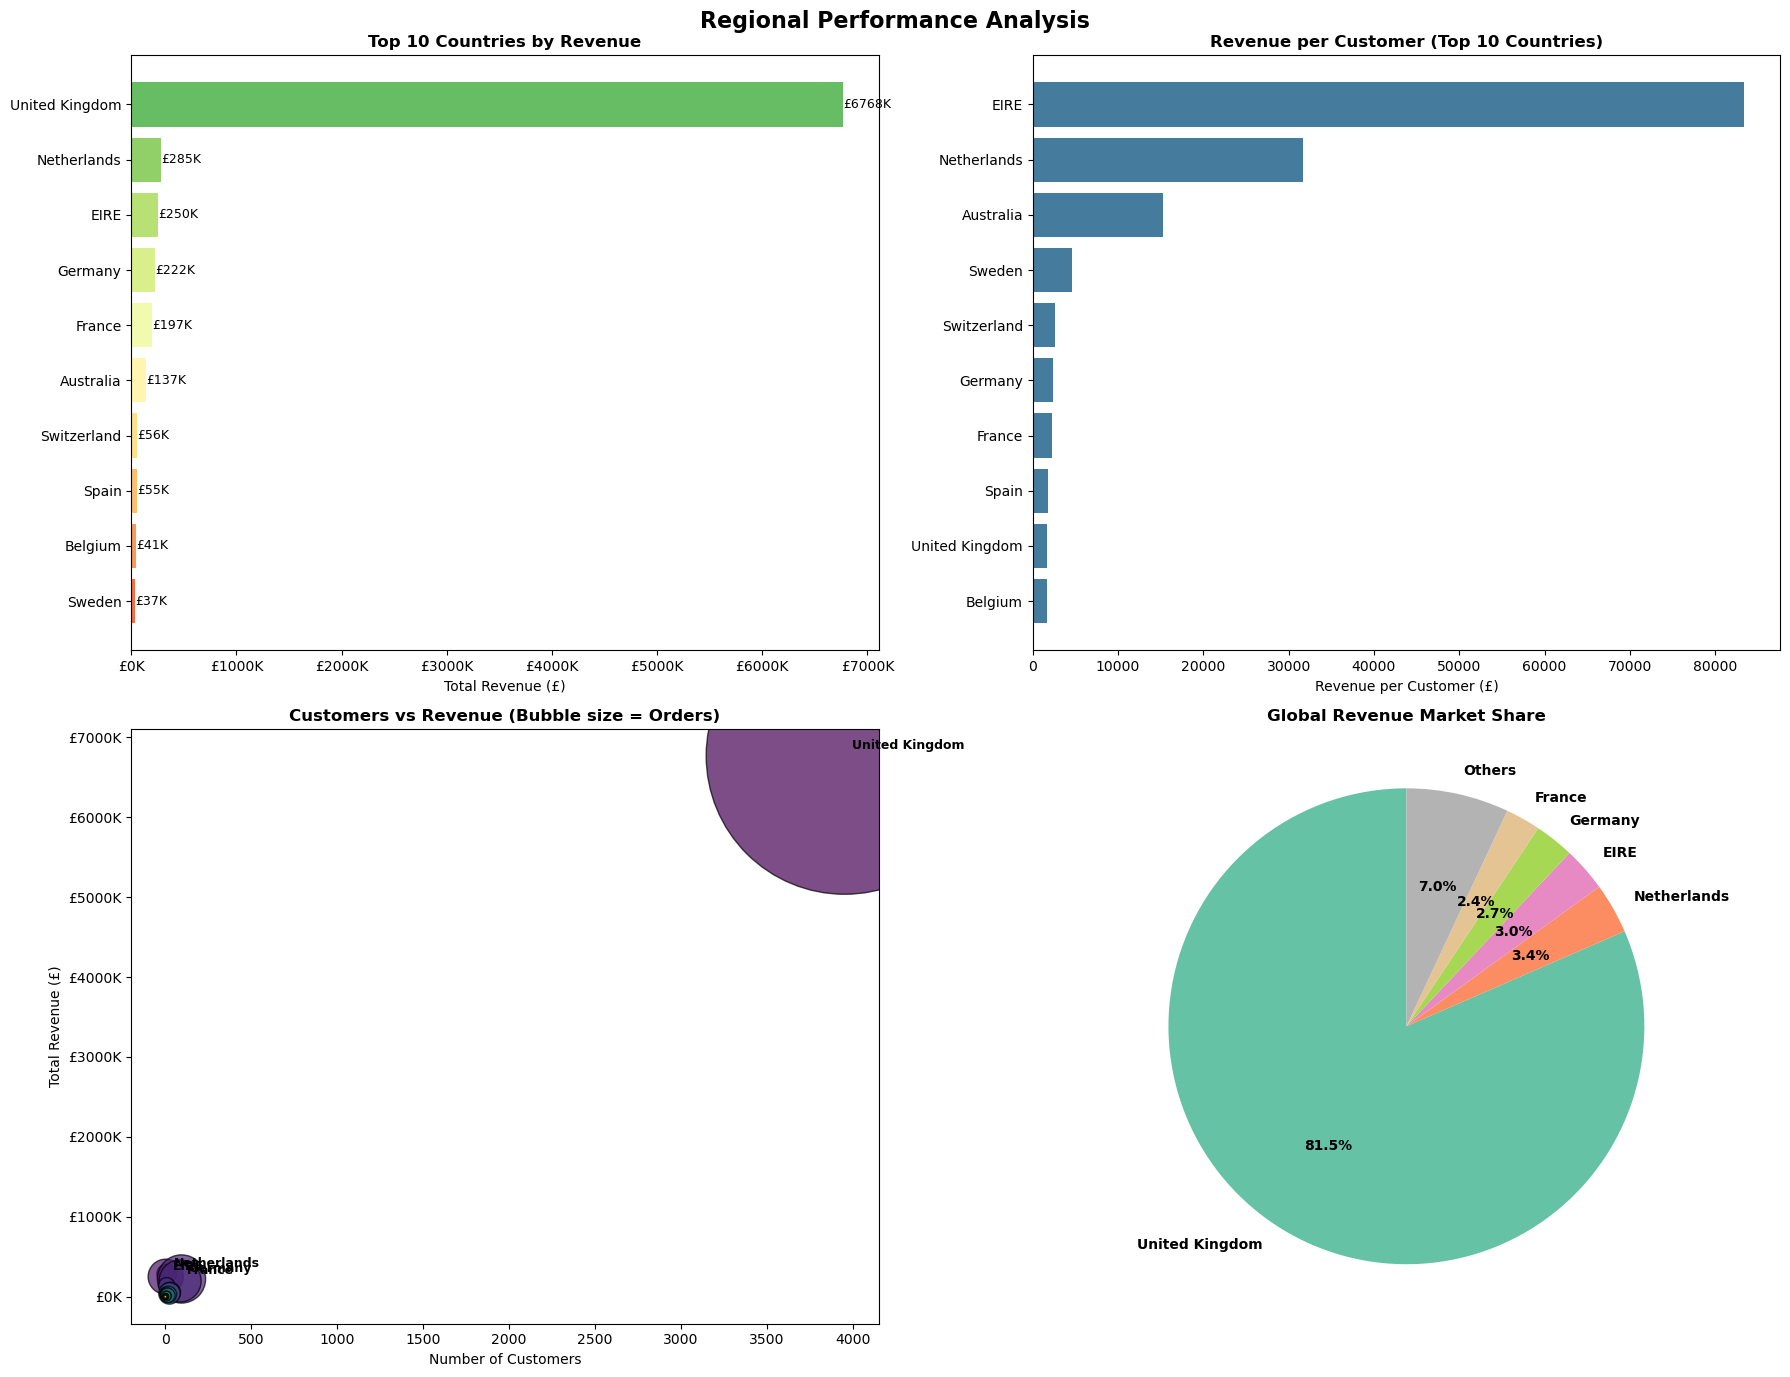


Key Regional Insights:
- Largest market: United Kingdom (£6,767,873.39, 81.5% of total)
- Highest revenue per customer: EIRE (£83428.41)
- Most active customers: EIRE (106.3 orders/customer)


In [15]:

# Country analysis
country_stats = Data_clean.groupby('Country').agg({
    'Revenue': ['sum', 'mean'],
    'Quantity': 'sum',
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique',
    'StockCode': 'nunique'
}).round(2)

country_stats.columns = ['Total_Revenue', 'Avg_Order_Value', 'Total_Quantity', 'Num_Orders', 'Num_Customers', 'Num_Products']
country_stats = country_stats.sort_values('Total_Revenue', ascending=False)

# Calculate additional metrics
country_stats['Revenue_per_Customer'] = (country_stats['Total_Revenue'] / country_stats['Num_Customers']).round(2)
country_stats['Orders_per_Customer'] = (country_stats['Num_Orders'] / country_stats['Num_Customers']).round(2)

country_stats.to_csv("/Users/promojz/Documents/Future Interns/Data/country statistics.csv", index=True)
print("\nTop 10 Countries by Revenue:")
print(country_stats.head(10).to_string())

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Regional Performance Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Revenue by Top 10 Countries
top_10_countries = country_stats.head(10).sort_values('Total_Revenue', ascending=True)
ax1 = axes[0, 0]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_10_countries)))
bars1 = ax1.barh(top_10_countries.index, top_10_countries['Total_Revenue'], color=colors)
ax1.set_xlabel('Total Revenue (£)')
ax1.set_title('Top 10 Countries by Revenue', fontweight='bold', fontsize=12)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, top_10_countries['Total_Revenue'])):
    ax1.text(val + 1000, bar.get_y() + bar.get_height()/2, 
             f'£{val/1000:.0f}K', va='center', fontsize=9)

# Plot 2: Revenue per Customer by Country
ax2 = axes[0, 1]
top_10_rpc = country_stats.head(10).sort_values('Revenue_per_Customer', ascending=True)
bars2 = ax2.barh(top_10_rpc.index, top_10_rpc['Revenue_per_Customer'], color='#457B9D')
ax2.set_xlabel('Revenue per Customer (£)')
ax2.set_title('Revenue per Customer (Top 10 Countries)', fontweight='bold', fontsize=12)

# Plot 3: Number of Customers vs Revenue
ax3 = axes[1, 0]
scatter = ax3.scatter(country_stats['Num_Customers'], country_stats['Total_Revenue'], 
                     s=country_stats['Num_Orders']*2, alpha=0.7, 
                     c=range(len(country_stats)), cmap='viridis', edgecolors='black')
ax3.set_xlabel('Number of Customers')
ax3.set_ylabel('Total Revenue (£)')
ax3.set_title('Customers vs Revenue (Bubble size = Orders)', fontweight='bold', fontsize=12)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Add country labels for top countries
for country, row in country_stats.head(5).iterrows():
    ax3.annotate(country, (row['Num_Customers'], row['Total_Revenue']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Plot 4: Market Share Pie Chart
ax4 = axes[1, 1]
top_5_countries = country_stats.head(5)['Total_Revenue']
other_countries_revenue = country_stats.iloc[5:]['Total_Revenue'].sum()
pie_data = list(top_5_countries.values) + [other_countries_revenue]
pie_labels = list(top_5_countries.index) + ['Others']

colors_pie = plt.cm.Set2(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = ax4.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', 
                                     colors=colors_pie, startangle=90,
                                     textprops={'fontsize': 10, 'fontweight': 'bold'})
ax4.set_title('Global Revenue Market Share', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('/Users/promojz/Documents/Future Interns/python_viz/regional_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Regional Insights:")
print(f"- Largest market: {country_stats.index[0]} (£{country_stats.iloc[0]['Total_Revenue']:,.2f}, {country_stats.iloc[0]['Total_Revenue']/country_stats['Total_Revenue'].sum()*100:.1f}% of total)")
print(f"- Highest revenue per customer: {country_stats.sort_values('Revenue_per_Customer', ascending=False).index[0]} (£{country_stats.sort_values('Revenue_per_Customer', ascending=False).iloc[0]['Revenue_per_Customer']:.2f})")
print(f"- Most active customers: {country_stats.sort_values('Orders_per_Customer', ascending=False).index[0]} ({country_stats.sort_values('Orders_per_Customer', ascending=False).iloc[0]['Orders_per_Customer']:.1f} orders/customer)")


In [16]:
country_stats

,Total_Revenue,Avg_Order_Value,Total_Quantity,Num_Orders,Num_Customers,Num_Products,Revenue_per_Customer,Orders_per_Customer
Country,,,,,,,,
United Kingdom,6767873.39,18.70,4008533,19857,3950,3661,1713.39,5.03
Netherlands,284661.54,120.06,200128,101,9,785,31629.06,11.22
EIRE,250285.22,33.44,136329,319,3,1950,83428.41,106.33
Germany,221698.21,23.35,117448,603,95,1671,2333.67,6.35
France,196712.84,23.17,109848,458,87,1523,2261.07,5.26
Australia,137077.27,108.88,83653,69,9,600,15230.81,7.67
Switzerland,55739.40,29.70,29778,71,21,947,2654.26,3.38
Spain,54774.58,21.62,26824,105,31,1093,1766.92,3.39
Belgium,40910.96,19.77,23152,119,25,778,1636.44,4.76


## Customer Analysis 


Customer Segmentation Summary:
                     Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Monetary  Percentage
Segment                                                                                         
Champions              840        10.39          14.62       6473.67      5437879.65        19.4
Lost                  2030       141.15           2.12        525.78      1067326.43        47.0
Loyal Customers        430        35.54           6.49       2205.22       948246.69         9.9
Cannot Lose Them       362       133.00           4.29       1513.84       548011.58         8.4
New Customers          205        15.71           1.87        600.98       123201.00         4.7
At Risk                 61       198.33           3.77       1788.77       109114.93         1.4
Potential Loyalists    271        27.44           1.15        219.30        59429.26         6.3
Hibernating            123        73.26           2.00        163.30        20085.41         2.

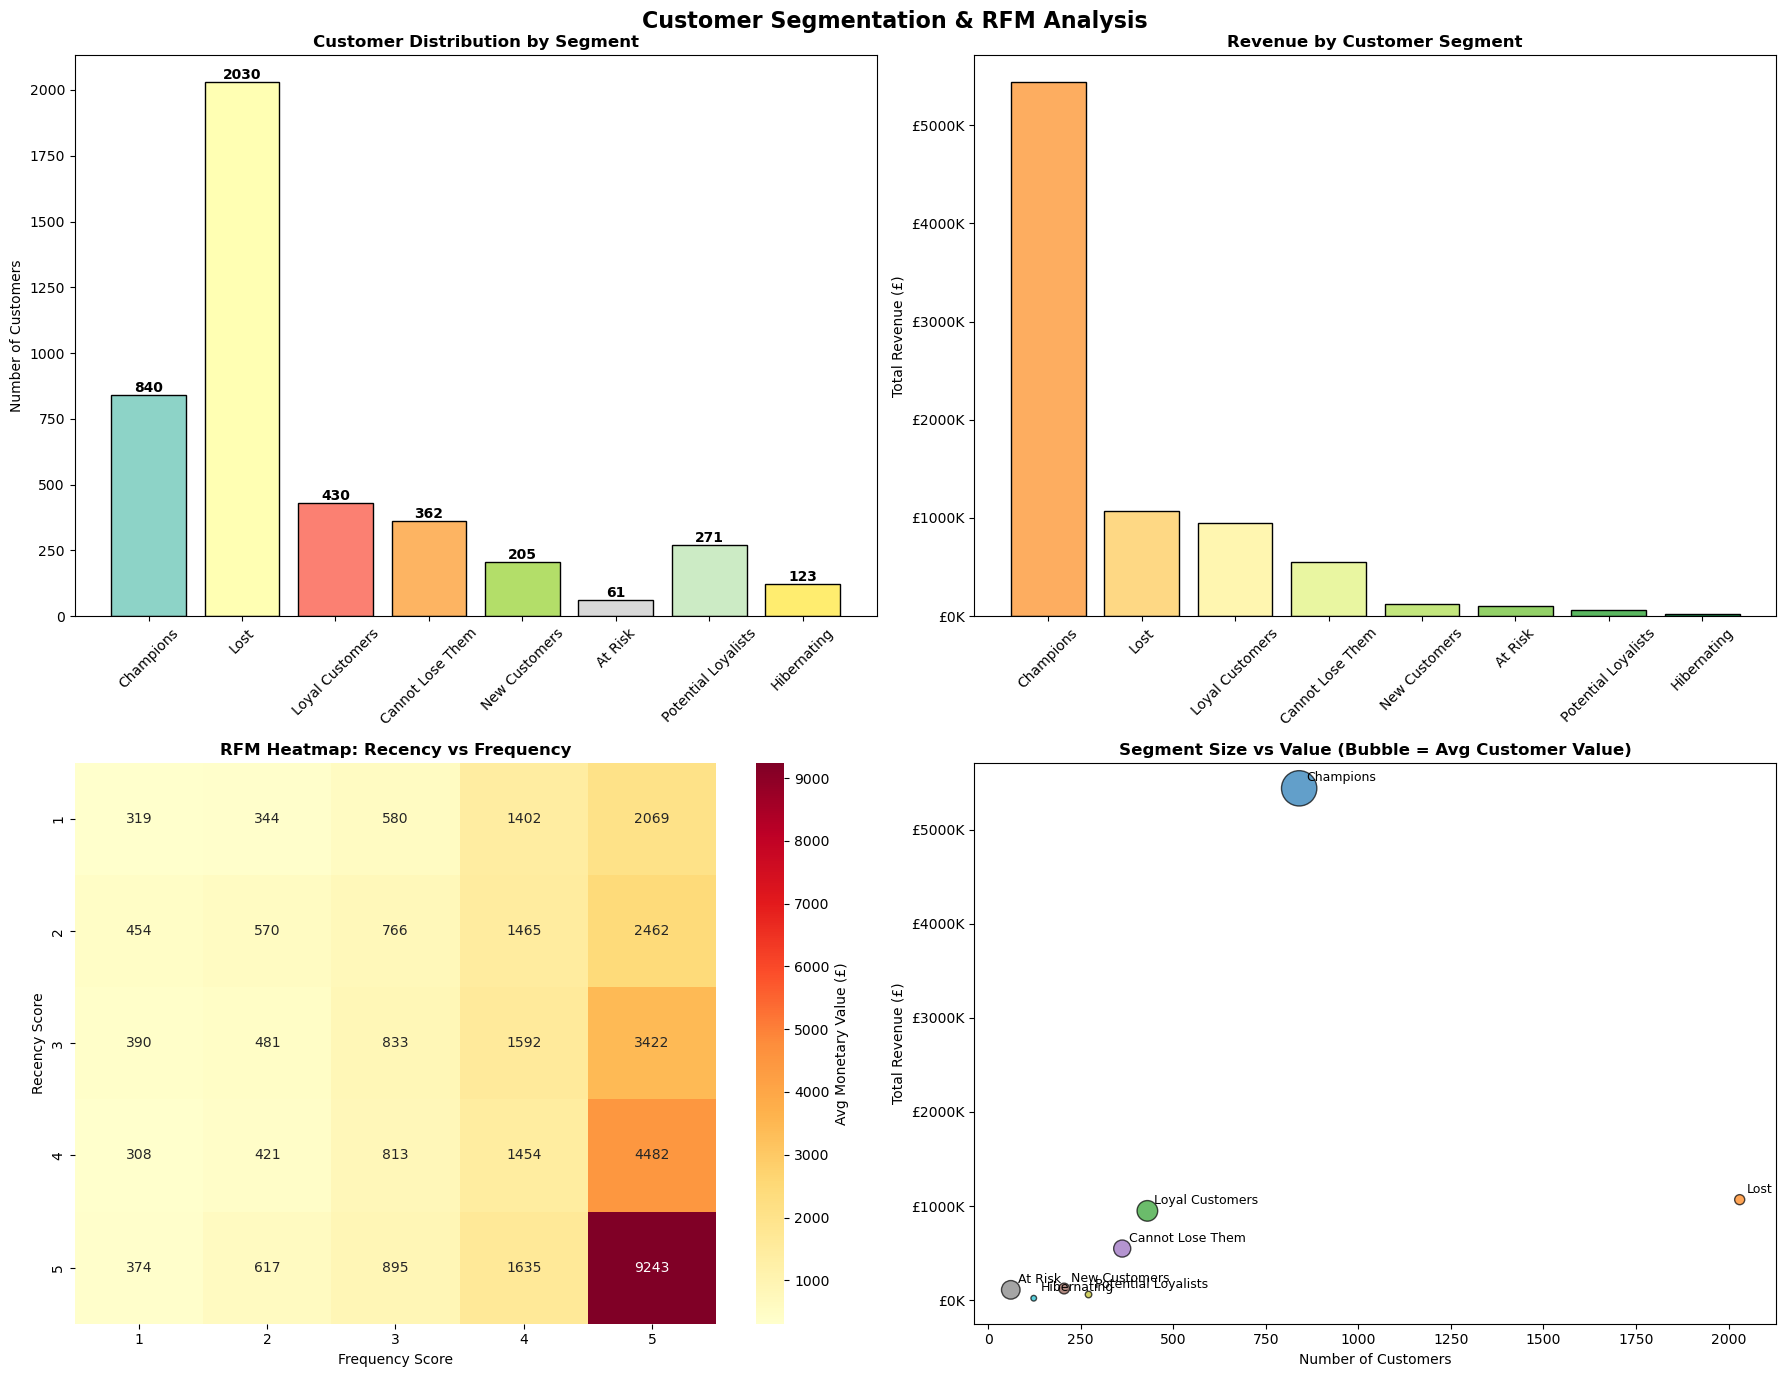


Key Customer Insights:
- Total customers: 4,322
- Top segment by revenue: Champions (£5,437,879.65)
- Most valuable customers (Champions): 840 customers
- At-risk customers: 61 customers - needs attention!


In [17]:

# Calculate RFM metrics
reference_date = Data_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = Data_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'Revenue': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Remove customers with negative monetary values (if any)
rfm = rfm[rfm['Monetary'] > 0]

# Create RFM scores (1-5, 5 being best)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])  # Lower recency = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Convert to numeric
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Create RFM combined score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Customer Segmentation based on RFM
def segment_customers(row):
    if row['RFM_Score'] in ['555', '554', '544', '545', '454', '455', '445']:
        return 'Champions'
    elif row['RFM_Score'] in ['543', '444', '435', '355', '354', '345', '344', '335']:
        return 'Loyal Customers'
    elif row['RFM_Score'] in ['512', '511', '422', '421', '412', '411', '311']:
        return 'Potential Loyalists'
    elif row['RFM_Score'] in ['533', '532', '531', '523', '522', '521', '515', '514', '513', '425', '424', '413', '414', '415', '315', '314', '313']:
        return 'New Customers'
    elif row['RFM_Score'] in ['155', '154', '144', '214', '215', '115', '114']:
        return 'At Risk'
    elif row['RFM_Score'] in ['155', '254', '245', '244', '253', '252', '243', '242', '235', '234', '225', '224', '153', '152', '145', '143', '142', '135', '134', '125', '124']:
        return 'Cannot Lose Them'
    elif row['RFM_Score'] in ['331', '321', '231', '241', '251']:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customers, axis=1)

# Segment analysis
segment_analysis = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).round(2)

segment_analysis.columns = ['Count', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Monetary']
segment_analysis['Percentage'] = (segment_analysis['Count'] / segment_analysis['Count'].sum() * 100).round(1)
segment_analysis = segment_analysis.sort_values('Total_Monetary', ascending=False)

print("\nCustomer Segmentation Summary:")
print(segment_analysis.to_string())

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Customer Segmentation & RFM Analysis', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Segment Distribution
ax1 = axes[0, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(segment_analysis)))
bars1 = ax1.bar(segment_analysis.index, segment_analysis['Count'], color=colors, edgecolor='black')
ax1.set_ylabel('Number of Customers')
ax1.set_title('Customer Distribution by Segment', fontweight='bold', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Revenue by Segment
ax2 = axes[0, 1]
bars2 = ax2.bar(segment_analysis.index, segment_analysis['Total_Monetary'], 
                color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(segment_analysis))), edgecolor='black')
ax2.set_ylabel('Total Revenue (£)')
ax2.set_title('Revenue by Customer Segment', fontweight='bold', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Plot 3: RFM Heatmap
ax3 = axes[1, 0]
rfm_pivot = rfm.groupby(['R_Score', 'F_Score'])['Monetary'].mean().unstack()
sns.heatmap(rfm_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'Avg Monetary Value (£)'})
ax3.set_title('RFM Heatmap: Recency vs Frequency', fontweight='bold', fontsize=12)
ax3.set_xlabel('Frequency Score')
ax3.set_ylabel('Recency Score')

# Plot 4: Segment Value Distribution
ax4 = axes[1, 1]
segment_value = segment_analysis[['Count', 'Total_Monetary']].copy()
segment_value['Avg_Value'] = segment_value['Total_Monetary'] / segment_value['Count']
scatter = ax4.scatter(segment_value['Count'], segment_value['Total_Monetary'], 
                     s=segment_value['Avg_Value']/10, alpha=0.7, 
                     c=range(len(segment_value)), cmap='tab10', edgecolors='black')
ax4.set_xlabel('Number of Customers')
ax4.set_ylabel('Total Revenue (£)')
ax4.set_title('Segment Size vs Value (Bubble = Avg Customer Value)', fontweight='bold', fontsize=12)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x/1000:.0f}K'))

# Add segment labels
for segment, row in segment_value.iterrows():
    ax4.annotate(segment, (row['Count'], row['Total_Monetary']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/promojz/Documents/Future Interns/python_viz/customer_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Customer Insights:")
print(f"- Total customers: {len(rfm):,}")
print(f"- Top segment by revenue: {segment_analysis.index[0]} (£{segment_analysis.iloc[0]['Total_Monetary']:,.2f})")
print(f"- Most valuable customers (Champions): {len(rfm[rfm['Segment']=='Champions']):,} customers")
print(f"- At-risk customers: {len(rfm[rfm['Segment']=='At Risk']):,} customers - needs attention!")


In [18]:
Data_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,YearMonth,DayOfWeek,Hour,IsReturn,IsCancelled,Category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2010-12,Wednesday,8,False,False,Lighting & Candles
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,False,False,Lighting & Candles
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2010-12,Wednesday,8,False,False,Hearts & Romance
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,False,False,Hot Water Bottles
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,False,False,Hearts & Romance


In [19]:
rfm

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
1,12347.0,2,7,4310.00,5,4,5,545,Champions
2,12348.0,75,4,1797.24,2,3,4,234,Cannot Lose Them
3,12349.0,19,1,1757.55,4,1,4,414,New Customers
4,12350.0,310,1,334.40,1,1,2,112,Lost
5,12352.0,36,11,1545.41,3,5,4,354,Loyal Customers
...,...,...,...,...,...,...,...,...,...
4367,18280.0,278,1,180.60,1,2,1,121,Lost
4368,18281.0,181,1,80.82,1,2,1,121,Lost
4369,18282.0,8,3,176.60,5,3,1,531,New Customers
4370,18283.0,4,16,2094.88,5,5,5,555,Champions
